# 04 Statistical Analysis

Use this notebook for deeper analysis such as correlation checks, hypothesis testing, forecasting, segmentation, or regression.

In [10]:
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

df = pd.read_csv("../data/processed/clean_retail_data.csv")

Pearson Correlation:
                 price_per_unit  quantity  total_spent
price_per_unit        1.000000  0.008390     0.601704
quantity              0.008390  1.000000     0.731243
total_spent           0.601704  0.731243     1.000000


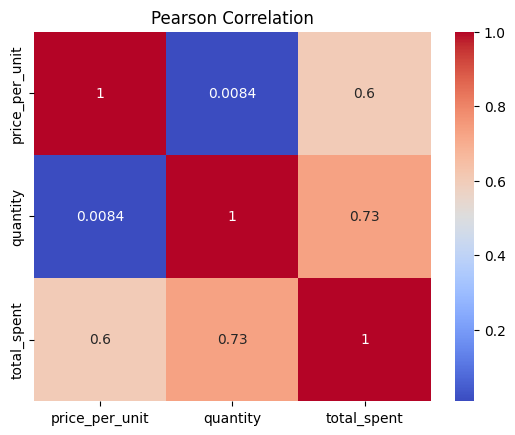

In [6]:

# Pearson Correlation
corr_pearson = df[["price_per_unit", "quantity", "total_spent"]].corr(method="pearson")
print("Pearson Correlation:\n", corr_pearson)

sns.heatmap(corr_pearson, annot=True, cmap="coolwarm")
plt.title("Pearson Correlation")
plt.show()

In [7]:
# Spearman Correlation
corr_spearman = df[["price_per_unit", "quantity", "total_spent"]].corr(method="spearman")
print("Spearman Correlation:\n", corr_spearman)

Spearman Correlation:
                 price_per_unit  quantity  total_spent
price_per_unit        1.000000  0.008279     0.593400
quantity              0.008279  1.000000     0.766226
total_spent           0.593400  0.766226     1.000000


In [6]:
#Spearman Correlation
corr_spearman = df[["price_per_unit", "quantity", "total_spent"]].corr(method="spearman")
print(corr_spearman)

                price_per_unit  quantity  total_spent
price_per_unit        1.000000  0.008279     0.593400
quantity              0.008279  1.000000     0.766226
total_spent           0.593400  0.766226     1.000000


In [8]:
print("Skewness:", df["total_spent"].skew())
print("Kurtosis:", df["total_spent"].kurt())

Skewness: 0.8718521618830765
Kurtosis: -0.0542735307126847


In [11]:
# Hypothesis Testing
# T-Test: Discount impact
discount = df[df["discount_applied"] == True]["total_spent"]
no_discount = df[df["discount_applied"] == False]["total_spent"]

t_stat, p_val = stats.ttest_ind(discount, no_discount)

print("T-stat:", t_stat)
print("P-value:", p_val)

T-stat: 0.7203305302467888
P-value: 0.4713349025656093


In [12]:
# ANOVA: Category impact
groups = [group["total_spent"].values for name, group in df.groupby("category")]

f_stat, p_val = f_oneway(*groups)

print("F-stat:", f_stat)
print("P-value:", p_val)

F-stat: 5.653482729625697
P-value: 1.5550245443743371e-06


In [13]:
# Customer Segmentation (RFM)
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

rfm = df.groupby("customer_id").agg({
    "transaction_date": lambda x: (df["transaction_date"].max() - x.max()).days,
    "transaction_id": "count",
    "total_spent": "sum"
})

rfm.columns = ["recency", "frequency", "monetary"]

rfm.head()

,recency,frequency,monetary
customer_id,,,
CUST_01,0,507,59315.5
CUST_02,2,488,62588.0
CUST_03,2,465,61314.0
CUST_04,0,474,62230.0
CUST_05,4,544,67584.0
